# Gaussian-splat decoder: one-target overfit report

This notebook summarizes the controlled decoder experiment on MCPP test target 0. Both variants used the same sampled molecule, 4,096 query points, occupancy targets, encoder initialization, 250 optimization steps, and a final full $128^3$ grid evaluation. The encoder was trainable in both runs.

> This is an optimization and representation diagnostic on one molecule—not test-set generalization performance.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

search_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    root for root in search_roots
    if (root / 'exps' / 'decoder_ablation').exists()
)
RESULT_PATH = (
    PROJECT_ROOT / 'exps' / 'decoder_ablation'
    / 'gpu2_fullgrid_validation_20260728' / 'comparison.json'
)
with RESULT_PATH.open() as handle:
    report = json.load(handle)
results = report['results']
RESULT_PATH

PosixPath('/home1/irteam/funcbind/exps/decoder_ablation/gpu2_fullgrid_validation_20260728/comparison.json')

## Learning behavior

![Sampled-point MSE and mIoU learning curves](figures/overfit_learning_curves.png)

Gaussian splatting converged to a lower sampled-point density error. Both methods fit the occupied sampled points well, so the full-grid check below is the more discriminating measurement.

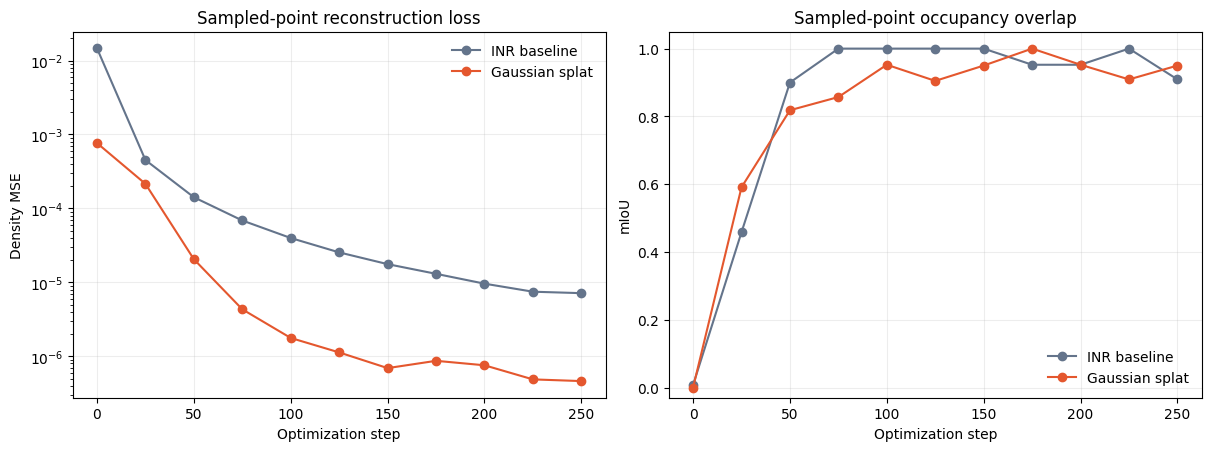

In [2]:
colors = {'inr': '#64748b', 'gaussian_splat': '#e4572e'}
labels = {'inr': 'INR baseline', 'gaussian_splat': 'Gaussian splat'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
for name in ('inr', 'gaussian_splat'):
    history = results[name]['history']
    steps = [point['step'] for point in history]
    axes[0].plot(steps, [point['density_mse'] for point in history],
                 marker='o', color=colors[name], label=labels[name])
    axes[1].plot(steps, [point['miou'] for point in history],
                 marker='o', color=colors[name], label=labels[name])
axes[0].set(yscale='log', xlabel='Optimization step', ylabel='Density MSE',
            title='Sampled-point reconstruction loss')
axes[1].set(xlabel='Optimization step', ylabel='mIoU',
            title='Sampled-point occupancy overlap', ylim=(-0.03, 1.05))
for axis in axes:
    axis.grid(alpha=0.22)
    axis.legend(frameon=False)
plt.show()

## Full-grid reconstruction and atom recovery

![Full-grid reconstruction, atom recovery, peak counts, and resource use](figures/overfit_fullgrid_summary.png)

The Gaussian decoder reduced full-grid density MSE and suppressed the INR baseline's large number of false peaks. Its precision and element accuracy improved substantially, but it predicted only 17 peaks for 57 target atoms; recall therefore remains the main failure mode.

In [3]:
rows = []
for name in ('inr', 'gaussian_splat'):
    result = results[name]
    full = result['full_grid']
    atoms = full['atom_recovery']
    rows.append({
        'decoder': labels[name],
        'sample MSE': result['final']['density_mse'],
        'sample mIoU': result['final']['miou'],
        'full-grid MSE': full['reconstruction']['density_mse'],
        'full-grid mIoU': full['reconstruction']['miou'],
        'atom precision': atoms['atom_precision'],
        'atom recall': atoms['atom_recall'],
        'atom F1': atoms['atom_f1'],
        'coordinate RMSD (Å)': atoms['coordinate_rmsd'],
        'element accuracy': atoms['element_accuracy'],
        'predicted / target atoms': f"{atoms['n_predicted_atoms']} / {atoms['n_target_atoms']}",
        'decoder parameters': result['decoder_parameters'],
        'mean step (s)': result['timing']['mean_step_seconds'],
        'peak training GPU (GiB)': result['timing']['peak_gpu_memory_gib'],
    })
pd.DataFrame(rows).set_index('decoder').T

decoder,INR baseline,Gaussian splat
sample MSE,0.000007,0.0
sample mIoU,0.909091,0.95
full-grid MSE,0.001634,0.000226
full-grid mIoU,0.010582,0.21845
atom precision,0.093137,0.705882
atom recall,0.333333,0.210526
atom F1,0.145594,0.324324
coordinate RMSD (Å),0.637134,0.595661
element accuracy,0.263158,0.833333
predicted / target atoms,204 / 57,17 / 57


## 3D occupancy comparison

The same full-grid occupancy threshold is shown for the reference, INR reconstruction, and Gaussian-splat reconstruction. Points are colored by atom channel and sized by occupancy. The static view below is pre-rendered; the following Plotly cell is interactive and CPU-only once the sparse point files exist.

![Reference, INR, and Gaussian-splat occupancy in 3D](figures/overfit_occupancy_3d.png)

In [4]:
OCCUPANCY_ROOT = (
    PROJECT_ROOT / 'exps' / 'decoder_ablation'
    / 'overfit_occupancy_visualization_20260728'
)
occupancy_paths = {
    'Reference': OCCUPANCY_ROOT / 'inr_gpu2' / 'target_000' / 'reference_occupancy_points.npz',
    'INR baseline': OCCUPANCY_ROOT / 'inr_gpu2' / 'target_000' / 'inr_occupancy_points.npz',
    'Gaussian splat': OCCUPANCY_ROOT / 'gaussian_splat_gpu3' / 'target_000' / 'gaussian_splat_occupancy_points.npz',
}

def load_occupancy_cloud(path):
    with np.load(path) as data:
        return {key: data[key] for key in data.files}

occupancy_clouds = {name: load_occupancy_cloud(path) for name, path in occupancy_paths.items()}
{name: cloud['coordinates'].shape[0] for name, cloud in occupancy_clouds.items()}

FileNotFoundError: [Errno 2] No such file or directory: '/home1/irteam/funcbind/exps/decoder_ablation/overfit_occupancy_visualization_20260728/inr_gpu2/target_000/reference_occupancy_points.npz'

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

elements = ('C', 'O', 'N', 'S', 'F', 'Cl', 'P', 'Br')
element_colors = ('#4b5563', '#dc2626', '#2563eb', '#eab308', '#22c55e', '#16a34a', '#f97316', '#92400e')
rng = np.random.default_rng(1234)
figure_3d = make_subplots(
    rows=1, cols=3, specs=[[{'type': 'scene'}] * 3],
    subplot_titles=list(occupancy_clouds),
)
for column, (title, cloud) in enumerate(occupancy_clouds.items(), start=1):
    for channel, (element, color) in enumerate(zip(elements, element_colors)):
        indices = np.flatnonzero(cloud['channels'] == channel)
        if indices.size > 5000:
            indices = rng.choice(indices, 5000, replace=False)
        if not indices.size:
            continue
        xyz = cloud['coordinates'][indices]
        values = cloud['occupancies'][indices].astype(np.float32)
        figure_3d.add_trace(
            go.Scatter3d(
                x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
                mode='markers', name=element, legendgroup=element,
                showlegend=(column == 1),
                marker={'size': 1.5 + 3.5 * values, 'color': color, 'opacity': 0.36},
                hovertemplate=(
                    f'{element}<br>x=%{{x:.2f}} Å<br>y=%{{y:.2f}} Å<br>'
                    'z=%{z:.2f} Å<extra></extra>'
                ),
            ),
            row=1, col=column,
        )
figure_3d.update_scenes(
    aspectmode='cube',
    xaxis_title='x (Å)', yaxis_title='y (Å)', zaxis_title='z (Å)',
)
threshold = float(occupancy_clouds['Reference']['threshold'])
figure_3d.update_layout(
    title=f'Full-grid occupancy ≥ {threshold:.2f}',
    width=1500, height=620, margin={'l': 0, 'r': 0, 'b': 0, 't': 70},
)
figure_3d.show()

## Interpretation

- **Representation:** the Gaussian head used 86,568 parameters versus 62.3 million for the INR decoder.
- **Density:** Gaussian splatting reduced full-grid MSE from $1.63\times10^{-3}$ to $2.26\times10^{-4}$.
- **Peak quality:** atom precision increased from 0.093 to 0.706 and element accuracy from 0.263 to 0.833.
- **Remaining issue:** atom recall decreased from 0.333 to 0.211 because the Gaussian decoder under-predicted peaks.
- **Next test:** the all-target MCPP reconstruction run should determine whether this precision/recall pattern is systematic and support threshold/opacity tuning.